In [1]:
import numpy as np
import torch
import random
import os

import pickle

from src.system import HydraulicSystem
# from src.simulator import Simulator
from src.simulator_casadi import create_simulator
from src.policy import PolicyREINFORCE, GaussianPDFModel, Optimizer
from src.scenario import MonteCarloSimulationScenario, SimulationScenario

from IPython.display import clear_output

import regelum as rg

data_path = './data'
os.path.isdir(data_path)
%matplotlib inline

## Set hyperparams

Total objective: 0.00279


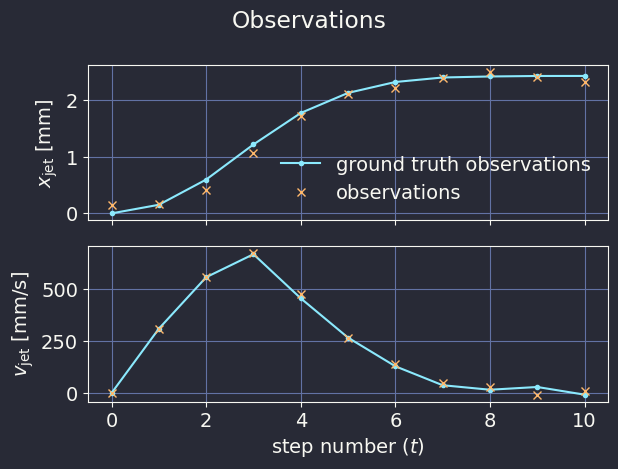

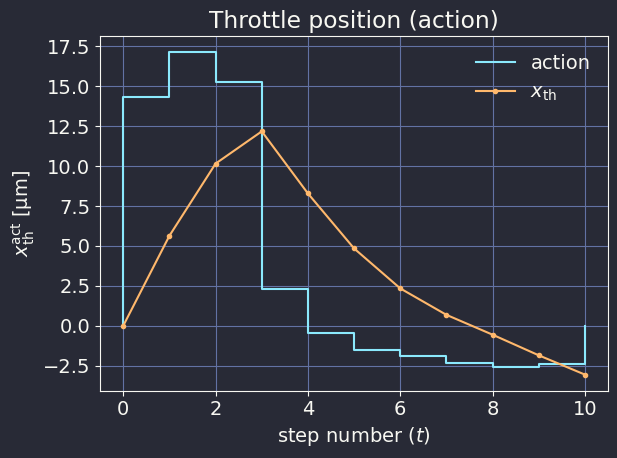

Relative jet length after the pulse: 1.264


In [2]:
SEED = 14
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

# Define the initial state
p_atm = 1e5
# initial_state = np.array([1e3, 0, 0, p_atm, p_atm])
initial_state = rg.array([1e3, 0, 0, p_atm, p_atm])

system = HydraulicSystem(
    init_state=initial_state,
    system_parameters_init = {
        "p_l_gauge": 1.5e5,
        "x_th_limits": (0., 20.),
        "freq_th": 500.0,
        "m_p": 20e-3,
        "D_th": 200e-6, # WAS 200e-6, then 5e-3
        "D_hydr": 20e-3,
        "D_work": 20e-3,
        "h_work_init": 1e3,
        "D_exit": 0.33e-3,
        "l_exit": 8.5e-3,
        "p_coulomb": 10e3, # WAS 10e3, then 1e3
        "eta": 0.70,
        "zeta_th": 5.0, # WAS 5.0, then 0.1
        "rho_hydr": 1e3,
        "rho_work": 1e3,
        "beta_v_hydr": 0.49e-9,
        "beta_v_work": 0.49e-9,
        "sigma_work": 73e-3,
        "mu_work": 1.0e-3,
        "v_j": 200.,
        "jet_length_std": 5e-2, # Was 5e-2
        "jet_velocity_std": 1e-2, # Was 1e-2
        "pressure_std": 0.,
        "p_atm": 1e5, # Atmosphere (ambient) pressure, Pa
        "g": 9.81, # gravity constant, m/s^2
    },
)

# Create CasADi simulator
simulator = create_simulator(
    simulator_type='casadi',
    system=system,
    N_steps=10,
    state_init=initial_state,
    integration_method='rk4',  # Change from 'collocation' to 'rk4'
    n_substeps=10000,
    use_symbolic=True,
)

model = torch.load(
    "models/model_policy_reinforce_less_frequency.pkl",
    map_location='cpu',
)

# Convert model to double precision to match the system data type
model = model.double()

model.l_crit = system._parameters["l_crit"]
model.sampling_time = simulator.step_size


scenario = SimulationScenario(
    simulator=simulator,
    policy=model,
    root_data_path=data_path,
    seed=SEED,
)

scenario.run()
scenario.plot_data(log_data=False)
rel_length = scenario.clean_observations[-1][0] / scenario.l_crit
print(
    f'Relative jet length after the pulse: {rel_length:.3f}'
)

Total objective: 0.00381


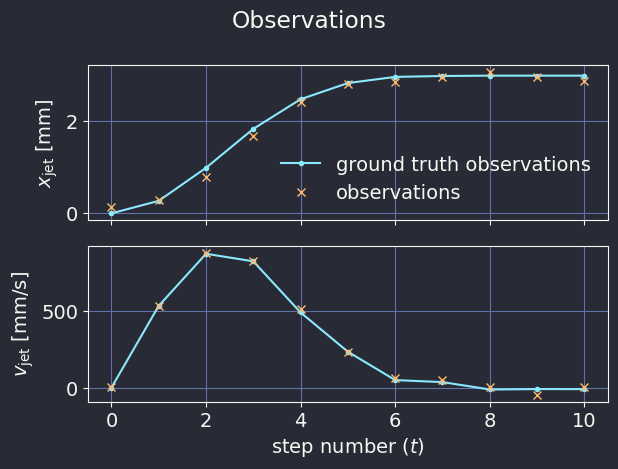

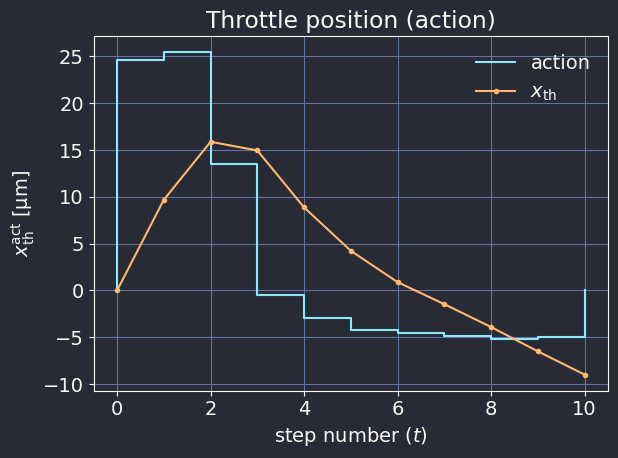

Relative jet length after the pulse: 1.557


In [3]:
SEED = 14
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

# Define the initial state
p_atm = 1e5
# initial_state = np.array([1e3, 0, 0, p_atm, p_atm])
initial_state = rg.array([1e3, 0, 0, p_atm, p_atm])

system = HydraulicSystem(
    init_state=initial_state,
    system_parameters_init = {
        "p_l_gauge": 1.5e5,
        "x_th_limits": (0., 20.),
        "freq_th": 500.0,
        "m_p": 20e-3,
        "D_th": 200e-6, # WAS 200e-6, then 5e-3
        "D_hydr": 20e-3,
        "D_work": 20e-3,
        "h_work_init": 1e3,
        "D_exit": 0.33e-3,
        "l_exit": 8.5e-3,
        "p_coulomb": 10e3, # WAS 10e3, then 1e3
        "eta": 0.70,
        "zeta_th": 5.0, # WAS 5.0, then 0.1
        "rho_hydr": 1e3,
        "rho_work": 1e3,
        "beta_v_hydr": 0.49e-9,
        "beta_v_work": 0.49e-9,
        "sigma_work": 73e-3,
        "mu_work": 1.0e-3,
        "v_j": 200.,
        "jet_length_std": 5e-2, # Was 5e-2
        "jet_velocity_std": 1e-2, # Was 1e-2
        "pressure_std": 0.,
        "p_atm": 1e5, # Atmosphere (ambient) pressure, Pa
        "g": 9.81, # gravity constant, m/s^2
    },
)

# Create CasADi simulator
simulator = create_simulator(
    simulator_type='casadi',
    system=system,
    N_steps=10,
    state_init=initial_state,
    integration_method='rk4',  # Change from 'collocation' to 'rk4'
    n_substeps=10000,
    use_symbolic=True,
)

model = torch.load(
    "models/model_policy_reinforce_noise.pkl",
    map_location='cpu',
)

# Convert model to double precision to match the system data type
model = model.double()

model.l_crit = system._parameters["l_crit"]
model.sampling_time = simulator.step_size


scenario = SimulationScenario(
    simulator=simulator,
    policy=model,
    root_data_path=data_path,
    seed=SEED,
)

scenario.run()
scenario.plot_data(log_data=False)
rel_length = scenario.clean_observations[-1][0] / scenario.l_crit
print(
    f'Relative jet length after the pulse: {rel_length:.3f}'
)

Total objective: 0.00318


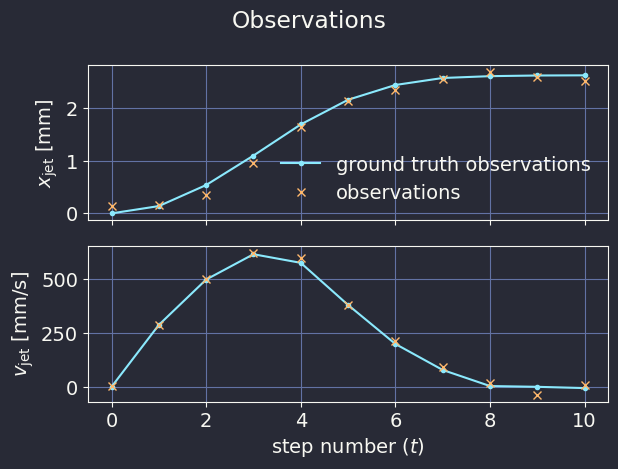

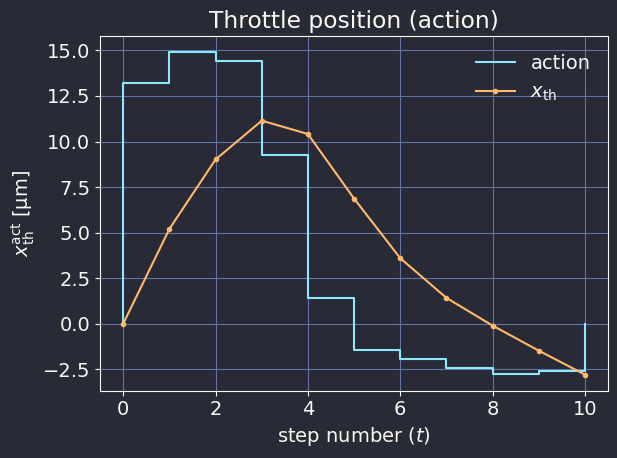

Relative jet length after the pulse: 1.367


In [4]:
SEED = 14
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

# Define the initial state
p_atm = 1e5
# initial_state = np.array([1e3, 0, 0, p_atm, p_atm])
initial_state = rg.array([1e3, 0, 0, p_atm, p_atm])

system = HydraulicSystem(
    init_state=initial_state,
    system_parameters_init = {
        "p_l_gauge": 1.5e5,
        "x_th_limits": (0., 20.),
        "freq_th": 500.0,
        "m_p": 20e-3,
        "D_th": 200e-6, # WAS 200e-6, then 5e-3
        "D_hydr": 20e-3,
        "D_work": 20e-3,
        "h_work_init": 1e3,
        "D_exit": 0.33e-3,
        "l_exit": 8.5e-3,
        "p_coulomb": 10e3, # WAS 10e3, then 1e3
        "eta": 0.70,
        "zeta_th": 5.0, # WAS 5.0, then 0.1
        "rho_hydr": 1e3,
        "rho_work": 1e3,
        "beta_v_hydr": 0.49e-9,
        "beta_v_work": 0.49e-9,
        "sigma_work": 73e-3,
        "mu_work": 1.0e-3,
        "v_j": 200.,
        "jet_length_std": 5e-2, # Was 5e-2
        "jet_velocity_std": 1e-2, # Was 1e-2
        "pressure_std": 0.,
        "p_atm": 1e5, # Atmosphere (ambient) pressure, Pa
        "g": 9.81, # gravity constant, m/s^2
    },
)

# Create CasADi simulator
simulator = create_simulator(
    simulator_type='casadi',
    system=system,
    N_steps=10,
    state_init=initial_state,
    integration_method='rk4',  # Change from 'collocation' to 'rk4'
    n_substeps=10000,
    use_symbolic=True,
)

model = torch.load(
    "models/model_policy_reinforce_noise_opt.pkl",
    map_location='cpu',
)

# Convert model to double precision to match the system data type
model = model.double()

model.l_crit = system._parameters["l_crit"]
model.sampling_time = simulator.step_size


scenario = SimulationScenario(
    simulator=simulator,
    policy=model,
    root_data_path=data_path,
    seed=SEED,
)

scenario.run()
scenario.plot_data(log_data=False)
rel_length = scenario.clean_observations[-1][0] / scenario.l_crit
print(
    f'Relative jet length after the pulse: {rel_length:.3f}'
)